In [37]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
img_path = r"C:\Users\vedhr\Downloads\La_Tour_Eiffel_vue_de_la_Tour_Saint-Jacques,_Paris_août_2014_(2).jpg"
img = cv.imread(img_path)


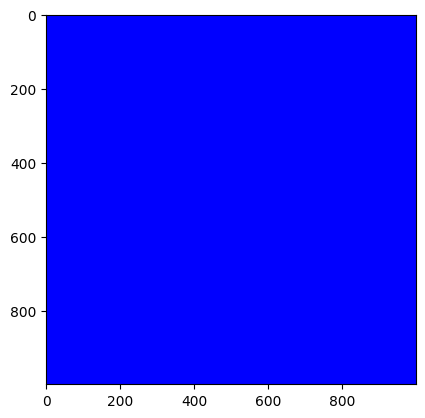

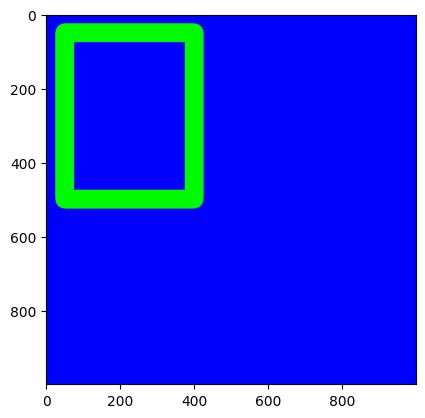

In [33]:
blank=np.zeros((1000,1000,3), dtype='uint8')
blank[:]=0,0,255
plt.imshow(blank)
plt.show()
## cv.shape(img_name,point1,point2,clour,thickness)
cv.rectangle(blank,(50,50),(400,500),(0,250,0),thickness=50)
plt.imshow(blank)
plt.show()

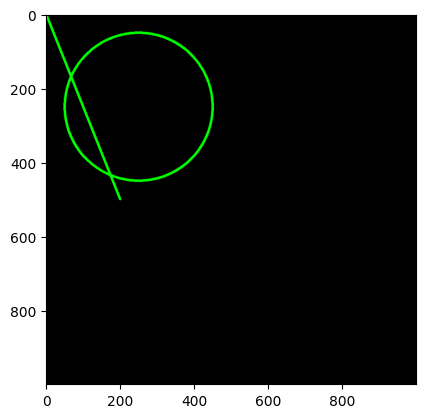

In [34]:
blank=np.zeros((1000,1000,3), dtype='uint8')
## cv.shape(img_name,point1,point2,radius,clour,thickness)
cv.circle(blank,(250,250),200,(0,255,0),thickness=6)
cv.line(blank,(0,0),(200,500),(0,255,0),thickness=6)
plt.imshow(blank)
plt.show()

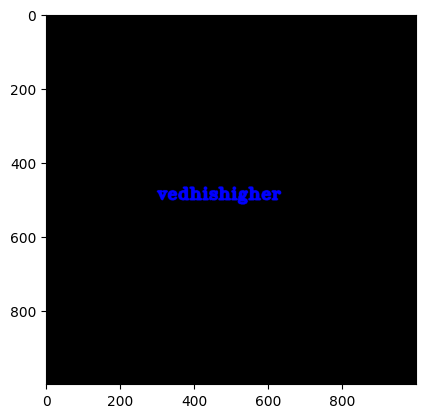

In [35]:
blank=np.zeros((1000,1000,3), dtype='uint8')
##text in images (VERY VERY importnant)
## cv.text(img_name,'input',(orgin),font,scale of font,colour,thickness)
cv.putText(blank,'vedhishigher',(300,500),cv.FONT_HERSHEY_TRIPLEX,1.5,(0,0,255),5)
plt.imshow(blank)
plt.show()

In [39]:


img = cv.imread(img_path)
if img is None:
    print("Error: Image not loaded correctly.")
else:
    # Convert to Grayscale
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    plt.imshow(gray, cmap='gray')
    plt.show()


Error: Image not loaded correctly. Check the file path and try again.


In [ ]:
# applying a blur (size should always be odd number)

blur=cv.GaussianBlur(img,(9,9),3)
plt.imshow(blur)
plt.show()

In [ ]:
# edges  (threshlod1,threshold2)

edg=cv.Canny(blur,125,175)
plt.imshow(edg)
plt.show

In [ ]:
# shifting of image

def translate(img,x,y):
    transmat = np.float32([[1,0,x],[0,1,y]])
    dimensions=(img.shape[1],img.shape[0])
    return cv.warpAffine (img,transmat,dimensions)
gg= translate(img,500,500)
plt.imshow(gg)
plt.show()
    

In [ ]:
# rotation

def rot(img,angle,point_of_rotation=None):
    if point_of_rotation is None:
        point_of_rotation=(1000,500)
        (width,height)=img.shape[:2]
    rotated=cv.getRotationMatrix2D(point_of_rotation,angle,1.0)
    dim=(width,height)
    return cv.warpAffine(img,rotated,dim)
ggg= rot(img,90)
plt.imshow(ggg)
plt.show()

In [ ]:
# flipping either 0,1,-1

flip=cv.flip(img ,0)
plt.imshow(flip)
plt.show()

In [ ]:
# contour used in detection


ret ,thresh=cv.threshold(edg,125,250,cv.THRESH_BINARY)
contours,hierarchies= cv.findContours(edg,cv.RETR_LIST,cv.CHAIN_APPROX_SIMPLE)
print(f"{len(contours)}")
plt.imshow(thresh)
plt.show()
blank=np.zeros(img.shape, dtype='uint8')
cdraw=cv.drawContours(blank,contours,-1,(0,255,0),1)
plt.imshow(cdraw)
plt.show()

In [ ]:
# color changing and also HSV which is better for definig image

imgc=cv.cvtColor(img,cv.COLOR_BGR2HSV)
imgl=cv.cvtColor(img,cv.COLOR_BGR2LAB)
plt.imshow(imgl)
plt.show()
plt.imshow(imgc)
plt.show()

In [ ]:
# color splitting

b,g,r=cv.split(img)
plt.imshow(img)
plt.show()
plt.imshow(r)
plt.show()
print(img.shape)
print(g.shape)
print(r.shape)
print("n\n\n\n\n")
merge=cv.merge([b,g,r])
plt.imshow(merge)
plt.show()

In [ ]:
# diff type of blur (kernal always odd)

blr=cv.blur(img,(51,51))
plt.imshow(blr)
plt.show()

In [ ]:
# bitwise operators

blank=np.zeros(img.shape, dtype='uint8')
rect=cv.rectangle(blank,(100,100),(800,800),255,-1)
circle=cv.circle(blank,(500,500),500,255,-1)

# bitwise and operator 

bit_and=cv.bitwise_and(rect,circle)

# bitwise or operator

bit_or=cv.bitwise_or(rect,circle)

plt.imshow(bit_or)
plt.show()
plt.imshow(bit_and)
plt.show()

In [ ]:
# bitwise XOR
XOR=cv.bitwise_xor(rect,circle)
plt.imshow(XOR)
plt.show()

In [ ]:
# masking

mask=cv.bitwise_and(img,img,mask=circle)
plt.imshow(mask)
plt.show()
